<a href="https://colab.research.google.com/github/ALDO12062004/EDP2/blob/main/M%C3%A9todo_de_Colocaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MÉTODO DE COLOCACIÓN

Considera el problema de valor inicial

$$u''+u=x \quad$$ con condiciones

con las condiciones $$u(0)=0 \quad \text{&} \quad  u'(0)=2$$

Encuentra una solución aproximada de la forma

$$u_N =\alpha_0 +\alpha_1 x + \alpha_2 x^2 + \alpha_3 x^3 + ...$$

(i) Elige $\alpha_0 $ y $ \alpha_1 $ para satisfacer las condiciones dadas, y encuentra el error $\varepsilon$ en este caso.

(ii) Define $\varepsilon=u_N''+u_N-x,$ y encuentra $\varepsilon$ en este caso

Restringiendo $u_N$ a ser un polinomio cúbico, usa $ x=\frac{1}{2}$ y $x=1$ como puntos de colocación para encontrar una solución aproximada.

---

***Solución***

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

Se importan las librerias Sympy para cálculo simbólico, numpy para convertir a un arreglo y matplotlib para graficar

#Solución de la EDO

$$u''+u=x$$

con

$$u(0)=0 \quad \text{ y } \quad u(0)'=2$$

In [2]:
x= sp.symbols('x') #introducimos una variable
u = sp.Function('u') #esto es una función

Se define una variable y una función para plantear y darle solución a la EDO

In [3]:
ode = u(x).diff(x,x) + u(x) -x #Esta es la forma de escribir la EDO con sympy
sp.dsolve(ode,u(x)) #Da la solución general de la EDO

Eq(u(x), C1*sin(x) + C2*cos(x) + x)

Se plantea y resuelve la EDO

In [4]:
sol = sp.dsolve(ode, ics={u(0):0, u(x).diff(x).subs(x, 0): 2}) #ics es una estructura de diccionario

Se introducen las condiciones iniciales para obtener una solución especifica

In [5]:
sol

Eq(u(x), x + sin(x))

Solución de la EDO una vez aplicadas las condiciones iniciales

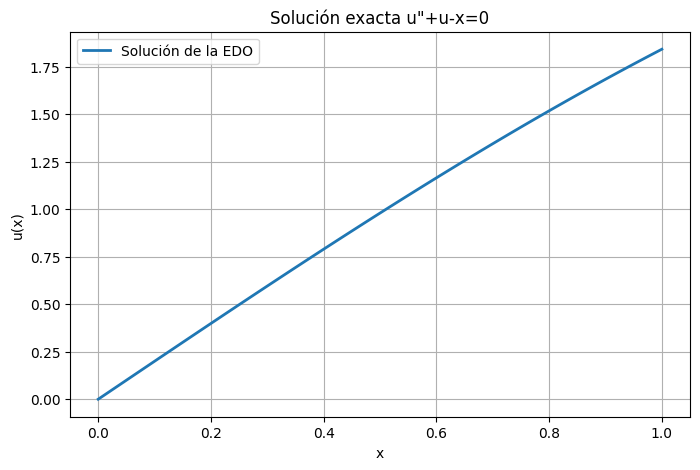

In [6]:
# convertimos en un arreglo
u_expr = sol.rhs

u_num = sp.lambdify(x,u_expr,"numpy")

xx = np.linspace(0,1,100)
yy = u_num(xx)

plt.figure(figsize=(8,5))
plt.plot(xx, yy, label=f'Solución de la EDO', linewidth=2)
plt.title('Solución exacta u"+u-x=0')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.grid(True)
plt.show()

Gráfica de la solución exacta de la EDO en el intervalo [0,1]

#Solución aproximada

De la forma (se restringe a un polinomio cúbico)

$$u_N =\alpha_0 +\alpha_1 x + \alpha_2 x^2 + \alpha_3x^3$$

Donde además

$$u_N(0)=0$$

$$u_N'(0)=2$$

Esto es:

$$u_N(0) =\alpha_0 =0$$

$$u_N' =\alpha_1 + 2\alpha_2 x + 3\alpha_3x^2$$

$$u'_N(0)=\alpha_1=2$$

Por lo tanto

$$\alpha_0=0 \quad \text{ y } \quad \alpha_1=2$$

$$u_N =2 x + \alpha_2 x^2 + \alpha_3x^3$$

In [7]:
a, b = sp.symbols('a b') #Simbolos

u_n = 2*x + a*x**2 +b*x**3

Se plantean  a y b como variables para el cálculo simbólico

In [8]:
u_n

a*x**2 + b*x**3 + 2*x

Propuesta de la solución

In [9]:
u_n_2 = sp.diff(u_n,x,2) #Se deriva dos veces la propuesta para eso se usa diff

F = u_n_2 + u_n - x

Se define el error $\varepsilon$ como F ya implementando la propuesta de la solución

In [10]:
F

a*x**2 + b*x**3 + x + 2*(a + 3*b*x)


Forma que tiene F (polinomio cúbico)


In [11]:
#Puntos de colocación

points = [sp.Rational(1,2),sp.Rational(1)]

Se usan los puntos de colocación $x=\frac{1}{2} $ y $ x=1$ para que de lugar a un sistema de ecuaciones

In [12]:
points

[1/2, 1]

In [13]:
eqs = [sp.Eq(F.subs(x,p),0) for p in points] #Ecuaciones del método

print("Sistema de ecuaciones simbólico:")
for eq in eqs:
    sp.pprint(eq)

Sistema de ecuaciones simbólico:
9⋅a   25⋅b   1    
─── + ──── + ─ = 0
 4     8     2    
3⋅a + 7⋅b + 1 = 0


Al sustituir los puntos de colocación se obtiene el sistema de ecuaciones

In [14]:
#Resolver para a y b
sol_1 = sp.solve(eqs,[a,b])

sol_1

{a: -1/17, b: -2/17}

Resolución del sistema de ecuaciones para $\alpha_2 $ y $ \alpha_3$ que eran los valores que se desconocian

In [15]:
#Sustituir en la función de prueba

u_approx=u_n.subs(sol_1)

Se sustituyen esos valores en la propuesta de solución dada anteriormente

$$u_N =2 x + \alpha_2 x^2 + \alpha_3x^3$$

In [16]:
u_approx

-2*x**3/17 - x**2/17 + 2*x

Ecuación obtenida tras sustituir los valores obtenidos

In [17]:
u_approx_fn = sp.lambdify(x,u_approx, "numpy") #Convierte a un arreglo numpy para graficar posteriormente

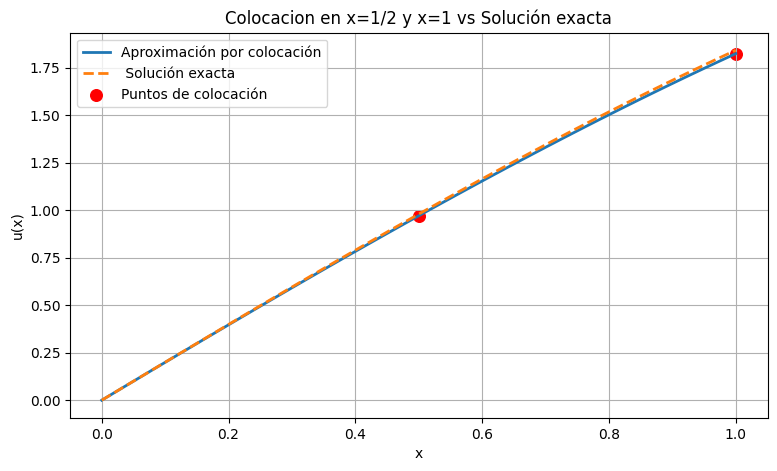

In [18]:
xx = np.linspace(0,1,100)

plt.figure(figsize=(9,5))
plt.plot(xx,u_approx_fn(xx), label="Aproximación por colocación", linewidth=2)
plt.plot(xx, yy, "--", label=" Solución exacta", linewidth=2)

#puntos de colocación
plt.scatter([0.5,1],u_approx_fn(np.array([0.5,1])),
            color="red", s=70, label="Puntos de colocación")

plt.title("Colocacion en x=1/2 y x=1 vs Solución exacta")
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.grid(True)
plt.show()

Gráfica comparativa de la solución propuesta vs la exacta en el intervalo [0,1] y puntos de colocación en $\frac{1}{2} $ y $ 1$.
Nótese que es una aproximación muy buena con un error pequeño para ese intervalo

#Error de la solución numérica

Se usó el error puntual o absoluto

$$E(x)=u(x)-u_N(x)$$

Es decir, en cada punto $x$ la diferencia entre la solución exacta y la aproximación.

In [19]:
# solución exacta
u_exact = x + sp.sin(x)

# solución numérica
u_N = -(sp.Rational(2,17))*x**3 - (sp.Rational(1,17))*x**2 + 2*x

# error simbólico
E = sp.simplify(u_exact - u_N)
sp.simplify(E)

2*x**3/17 + x**2/17 - x + sin(x)

Este es el error "general" de la función, solo bastaría seleccionar un punto y evaluar en $E(x)$ para obtener una representación numérica del error en dicho punto